**Executive Summary**

Analyzed 7,043 telecom customers to understand and predict churn (26.5% overall).

Risk profile:
churn concentrates in new customers (53% in first 6 months), 
on month-to-month contracts (43% vs 3% for two-year), 
using fiber optic internet (42%), 
without tech support (42%), 
paying by electronic check (45%).
    
**Model**: a class-weighted Random Forest (max_depth=5) catches 82% of churners before they leave (recall 0.82). EDA, logistic regression coefficients, and random forest feature importances independently confirmed the same risk profile.

**Recommendations**: target first-6-month, month-to-month fiber customers with long-term contract offers bundled with tech support; incentivize switching from manual electronic check to automatic payments.

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [161]:

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [162]:
df.shape


(7043, 21)

In [163]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [164]:

df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [165]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [166]:
df[df["TotalCharges"].isna()][["customerID", "tenure", "TotalCharges"]]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN


In [167]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)


In [168]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

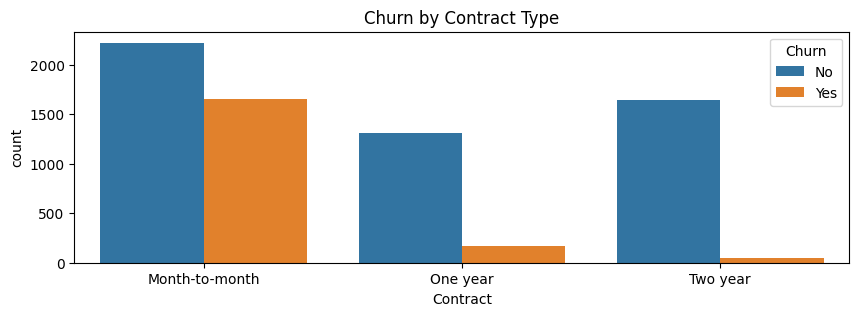

In [169]:
plt.figure(figsize=(10,3))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

In [170]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

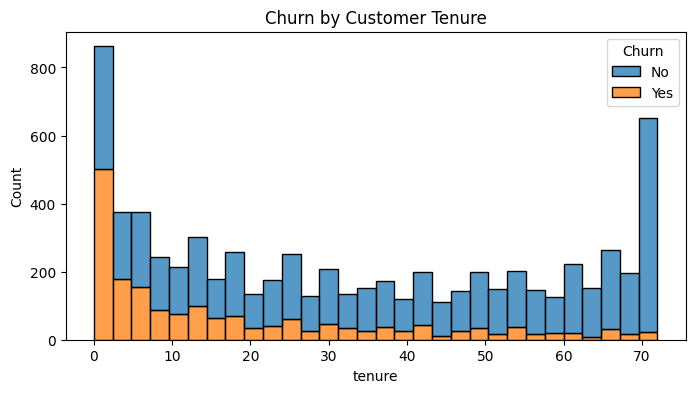

In [171]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.title("Churn by Customer Tenure")
plt.show()

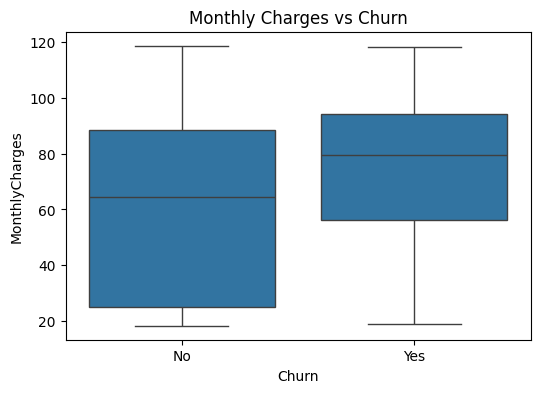

In [172]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

We analyzed three parameters:
- Contract duration
- New vs. existing customer status
- Price
-----------
We observe the following:
- Churn rates are higher among customers who have higher bills, are in the onboarding phase, and hold monthly contracts.

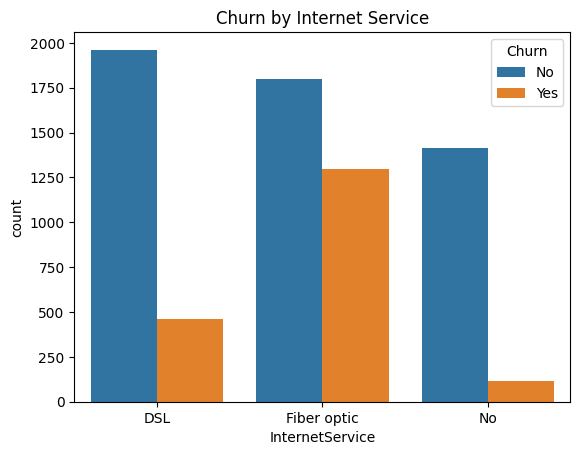

In [173]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

In [174]:
df[df["InternetService"] == "Fiber optic"].groupby("TechSupport")["Churn"].value_counts(normalize=True)

TechSupport  Churn
No           No       0.506278
             Yes      0.493722
Yes          No       0.773672
             Yes      0.226328
Name: proportion, dtype: float64

The profile at highest risk of churn is a fiber customer on a month-to-month contract—specifically one in their initial months with a high bill—who does not receive technical support and pays their bill manually (via electronic check) each month. The churn rate is approximately 43% for month-to-month customers, compared to about 3% for those on two-year contracts. Customer loyalty is significantly higher among those who receive technical support. Recommendation: Offer long-term contracts combined with technical support packages to fiber customers in their early months, and incentivize the switch to automatic payments by offering a small discount.

In [175]:
# Bin numerical variables into groups (so they can appear in the summary table)
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                           labels=["0-6 mo", "7-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])
df["ChargeGroup"] = pd.cut(df["MonthlyCharges"], bins=[0, 35, 70, 120],
                           labels=["Low (<$35)", "Mid ($35-70)", "High (>$70)"])

parameters = ["Contract", "TenureGroup", "ChargeGroup",
              "InternetService", "TechSupport", "PaymentMethod"]

rows = []
for p in parameters:
    grp = df.groupby(p, observed=True)["Churn"]
    summary = pd.DataFrame({
        "Parameter": p,
        "Category": grp.count().index,
        "Customer Count": grp.count().values,
        "Churn Rate (%)": (grp.apply(lambda s: (s == "Yes").mean()) * 100).round(1).values
    })
    rows.append(summary)

evidence = pd.concat(rows, ignore_index=True)
evidence.sort_values(["Parameter", "Churn Rate (%)"], ascending=[True, False])

,Parameter,Category,Customer Count,Churn Rate (%)
10,ChargeGroup,High (>$70),3583,35.4
9,ChargeGroup,Mid ($35-70),1725,23.9
8,ChargeGroup,Low (<$35),1735,10.9
0,Contract,Month-to-month,3875,42.7
1,Contract,One year,1473,11.3
2,Contract,Two year,1695,2.8
12,InternetService,Fiber optic,3096,41.9
11,InternetService,DSL,2421,19.0
13,InternetService,No,1526,7.4
19,PaymentMethod,Electronic check,2365,45.3


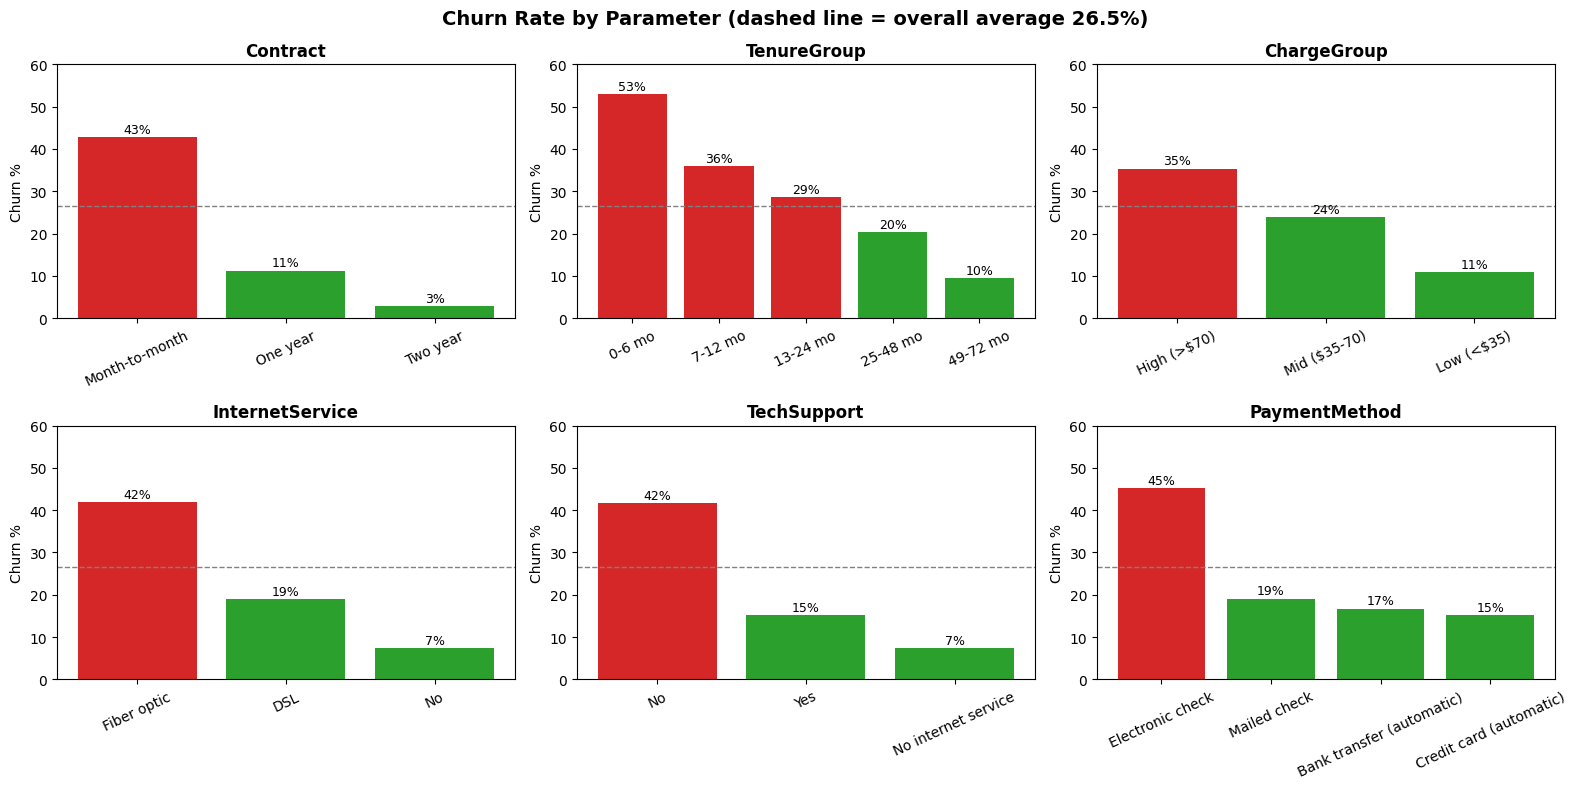

In [176]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
overall_rate = (df["Churn"] == "Yes").mean() * 100

for ax, p in zip(axes.flatten(), parameters):
    rates = (df.groupby(p, observed=True)["Churn"]
               .apply(lambda s: (s == "Yes").mean() * 100)
               .sort_values(ascending=False))
    colors = ["#d62728" if v > overall_rate else "#2ca02c" for v in rates.values]
    ax.bar(rates.index.astype(str), rates.values, color=colors)
    ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1)
    ax.set_title(p, fontsize=12, fontweight="bold")
    ax.set_ylabel("Churn %")
    ax.set_ylim(0, 60)
    ax.tick_params(axis="x", rotation=25)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

plt.suptitle(f"Churn Rate by Parameter (dashed line = overall average {overall_rate:.1f}%)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [177]:
# --- Stage 4: prepare data for modeling ---
df_model = df.drop(columns=["customerID", "TenureGroup", "ChargeGroup"])
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [178]:

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=2000))])

In [179]:
weights = pd.Series(model.named_steps["logisticregression"].coef_[0],
                    index=X.columns).sort_values()
weights

tenure                                  -1.236528
MonthlyCharges                          -0.920153
Contract_Two year                       -0.586859
Contract_One year                       -0.285509
OnlineSecurity_Yes                      -0.123561
Dependents_Yes                          -0.103550
TechSupport_Yes                         -0.100502
OnlineBackup_No internet service        -0.092761
DeviceProtection_No internet service    -0.092761
TechSupport_No internet service         -0.092761
StreamingTV_No internet service         -0.092761
StreamingMovies_No internet service     -0.092761
InternetService_No                      -0.092761
OnlineSecurity_No internet service      -0.092761
PaymentMethod_Credit card (automatic)   -0.013039
OnlineBackup_Yes                        -0.012022
MultipleLines_No phone service          -0.006794
PhoneService_Yes                         0.006794
Partner_Yes                              0.010866
gender_Male                              0.011094


In [180]:
y_pred = model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))

Accuracy : 0.807
Recall   : 0.567
Precision: 0.658


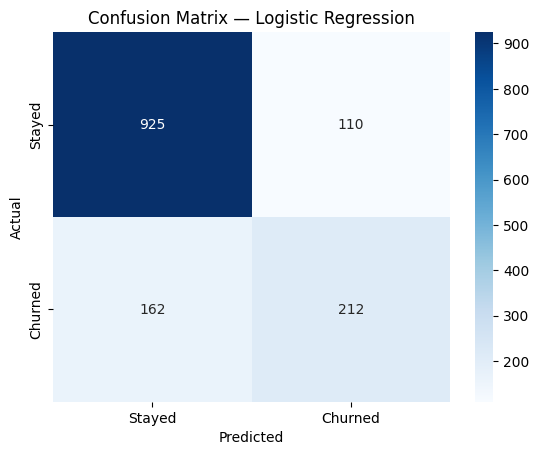

In [181]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed","Churned"], yticklabels=["Stayed","Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show() 

In [182]:
model_bal = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000, class_weight="balanced"))
model_bal.fit(X_train, y_train)
y_pred_bal = model_bal.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_bal), 3))
print("Recall   :", round(recall_score(y_test, y_pred_bal), 3))
print("Precision:", round(precision_score(y_test, y_pred_bal), 3))

Accuracy : 0.74
Recall   : 0.786
Precision: 0.507


Model selection rationale: Metric choice is a business decision, not a technical one. When the two error types have asymmetric costs, we optimize the metric that reduces the expensive error. Here, a missed churner costs ~$840/year in lost revenue, while a false alarm costs only ~$20 (an unnecessary retention offer) — roughly a 40x asymmetry. We therefore prioritized recall and selected the class-weighted model (recall 0.79 vs 0.57), accepting lower precision as a trade-off.

Further tuning: The default 0.5 decision threshold is adjustable. Using predict_proba, the threshold can be lowered to increase recall or raised to increase precision, allowing the operating point to be set based on the retention campaign budget (threshold tuning).

In [183]:
rf = RandomForestClassifier(n_estimators=10, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))

Accuracy : 0.771
Recall   : 0.447
Precision: 0.59


In [185]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))

Accuracy : 0.79
Recall   : 0.495
Precision: 0.634


Hyperparameter findings: (1) Increasing n_estimators improves performance with diminishing returns beyond ~100 trees. (2) With unlimited depth, trees grow pure leaves and class weights lose their effect — the forest reverts to majority-class behavior (recall 0.50). (3) Limiting max_depth to 5 keeps leaves impure, letting class weights act, which lifted recall to 0.82. Complexity must be tuned to the objective, not maximized.

In [186]:
# Final model: shallow forest lets class weights act
rf = RandomForestClassifier(n_estimators=300, max_depth=5,
                            class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))

Accuracy : 0.737
Recall   : 0.816
Precision: 0.502


In [187]:
# Final model: shallow forest lets class weights act
rf = RandomForestClassifier(n_estimators=300, max_depth=5,
                            class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))

Accuracy : 0.737
Recall   : 0.816
Precision: 0.502


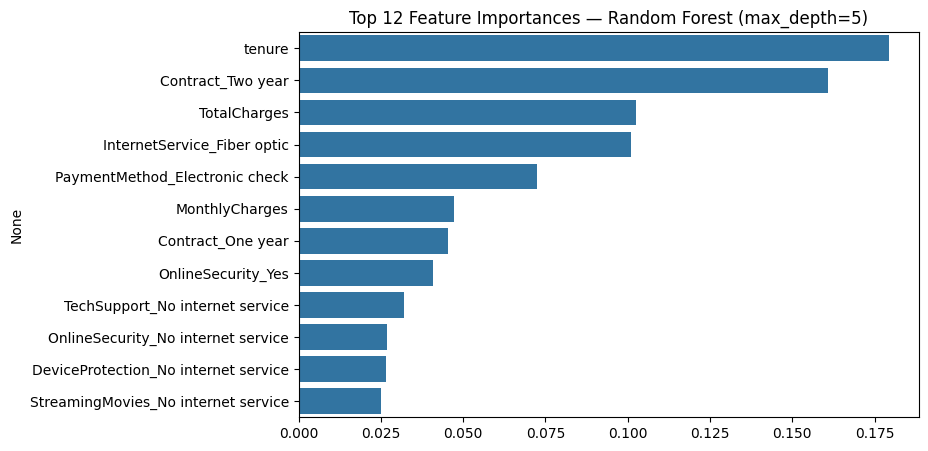

In [188]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 12 Feature Importances — Random Forest (max_depth=5)")
plt.show()